In [ ]:
# Setup cell — run this first
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.datasets import make_classification, make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
print("✅ Ready. Let's build a brain from scratch.")

✅ Ready. Let's build a brain from scratch.


**What id Nueral Network?**

The analogy - A company with departments

Imagine a company trying to decide whether to approve a loan application.

- Floor 1 (Input Layer): The raw data arrives, age, salary, credit score, debt
- Floor 2 (Hidden Layer 1): One department looks at this data and creates internal signals, "This person seems financially stable" or "this person has high debt relative to income"
- Another department combines those signals, "stable income + low debt = low risk"
- Final decision, approve or deny

Each floor takes the previous floor's output, processes it, and passes a new signal upward, nobody on floor 3 looks at the raw data directly, they only see what floor 2 concluded. **This is Neural Network.**

Why Stack Layers?

A singles logistic regression (one layer) can only draw **one straight line** as a decision boundary. Real problems are never that simple.

By stacking layers:
- Layer 1 Learns simple patterns(edges, basic relationships)
- Layer 2 combines simple patters into complex ones
- Layer 3 combines complex patterns into higher concepts

The key ingredient that makes stacking work: non-linear activation functions between layers. Without them, stacking layers is mathematically identical to having one layer, they collapse into single linear transformation.

Wiyout activation functions:
- Layer 1=W1 × input
- Layer 2-W2 ×  Layer 1 = W2 × W1 × input = (W2 ×  W1) × input

This is just One matrix multiplication. Pointless stacking.

With activation functions:
- Layer 1= activation(W1 ×  input) <--- non-linear
- Layer 2= activation(W2 × Layer1) <--- non-linear

Now layer 2 can represent things Layer1 cannot.

Each Layer genuinely adds expressive power.

**KEY TERMS**

**Neuron**

One unit that takes input, multiplies by weights, add bias, passes through activation

**Layer**

A group of neurons that all recieve the same input and process it in parallel

**Weight(W)**

The strength of connection between neurons. What the network learns

**Bias(b)**

A constant added to shift the activation. Lets the neuron fire even when inputs are zero

**Activation Function**

A non-linear function applied after the weighted sum. The secret ingredient

**Forward pass**

Data flowing from input to output through all layers

**Backward pass**

Data flowing from input ---> output to update weights

**Epoch**

One complete pass through the entire training dataset


ONE NEURON, Step by Step

A single neuron does exactly 3 things:
1. Multiply each input by its weight
2. Add all those products together, plus a bias
3. Pass the result through an activation function

Inputs:       [0.8 0.3 0.5]
Weights:      [ 0.4 -0.2  0.7]
Bias:         0.1

Weighted sum: 0.8×0.4 + 0.3×-0.2 + 0.5×0.7 + 0.1
            = 0.7100

After sigmoid: sigmoid(0.7100) = 0.6704

Interpretation: this neuron is 67.0% 'activated'
It's saying: 'I'm 67% confident this pattern exists'


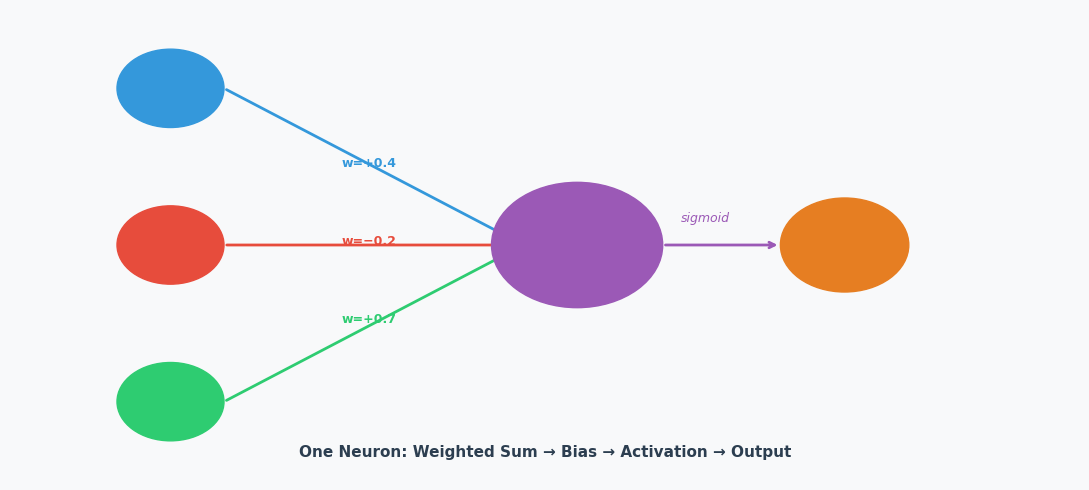

In [ ]:
# WHAT DOES ONE NEURON ACTUALLY DO?

print("ONE NEURON, Step by Step")
print("=" * 45)
print()
print("A single neuron does exactly 3 things:")
print("1. Multiply each input by its weight")
print("2. Add all those products together, plus a bias")
print("3. Pass the result through an activation function")
print()

# Simulate one neuron with 3 inputs
inputs  = np.array([0.8, 0.3, 0.5])   # raw features
weights = np.array([0.4, -0.2, 0.7])  # learned weights
bias    = 0.1                          # learned bias

# Step 1+2: weighted sum (this is the "linear" part)
weighted_sum = np.dot(inputs, weights) + bias
print(f"Inputs:       {inputs}")
print(f"Weights:      {weights}")
print(f"Bias:         {bias}")
print()
print(f"Weighted sum: {inputs[0]}×{weights[0]} + "
      f"{inputs[1]}×{weights[1]} + "
      f"{inputs[2]}×{weights[2]} + {bias}")
print(f"            = {weighted_sum:.4f}")
print()

# Step 3: activation function (this is the "non-linear" part)
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

output = sigmoid(weighted_sum)
print(f"After sigmoid: sigmoid({weighted_sum:.4f}) = {output:.4f}")
print()
print(f"Interpretation: this neuron is {output:.1%} 'activated'")
print(f"It's saying: 'I'm {output:.0%} confident this pattern exists'")

# Visualise the neuron visually
fig, ax = plt.subplots(figsize=(11, 5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.axis('off')
ax.set_facecolor('#F8F9FA')
fig.patch.set_facecolor('#F8F9FA')

# Input nodes
input_labels = ['Input 1\n(0.8)', 'Input 2\n(0.3)', 'Input 3\n(0.5)']
input_y      = [5.0, 3.0, 1.0]
weight_labels = ['w=+0.4', 'w=−0.2', 'w=+0.7']
colors_inp   = ['#3498DB', '#E74C3C', '#2ECC71']

for i, (y_pos, label, w_label, col) in enumerate(
        zip(input_y, input_labels, weight_labels, colors_inp)):
    circle = plt.Circle((1.5, y_pos), 0.5,
                          color=col, zorder=5)
    ax.add_patch(circle)
    ax.text(1.5, y_pos, label, ha='center',
            va='center', fontsize=8,
            fontweight='bold', color='white')
    # Arrow to neuron
    ax.annotate('', xy=(4.8, 3.0), xytext=(2.0, y_pos),
                arrowprops=dict(arrowstyle='->',
                                color=col, lw=2))
    # Weight label on arrow
    mid_x = (2.0 + 4.8) / 2 - 0.3
    mid_y = (y_pos + 3.0) / 2
    ax.text(mid_x, mid_y, w_label,
            fontsize=9, color=col, fontweight='bold')

# Neuron node
neuron = plt.Circle((5.3, 3.0), 0.8,
                     color='#9B59B6', zorder=5)
ax.add_patch(neuron)
ax.text(5.3, 3.2, 'Σ + b', ha='center',
        va='center', fontsize=11,
        fontweight='bold', color='white')
ax.text(5.3, 2.7, f'={weighted_sum:.2f}',
        ha='center', va='center',
        fontsize=9, color='#F0E6FF')

# Activation arrow
ax.annotate('', xy=(7.2, 3.0), xytext=(6.1, 3.0),
            arrowprops=dict(arrowstyle='->',
                            color='#9B59B6', lw=2))
ax.text(6.5, 3.3, 'sigmoid', ha='center',
        fontsize=9, color='#9B59B6',
        fontstyle='italic')

# Output node
out_circle = plt.Circle((7.8, 3.0), 0.6,
                          color='#E67E22', zorder=5)
ax.add_patch(out_circle)
ax.text(7.8, 3.0, f'{output:.3f}',
        ha='center', va='center',
        fontsize=11, fontweight='bold',
        color='white')

ax.text(5.0, 0.3,
        'One Neuron: Weighted Sum → Bias → Activation → Output',
        ha='center', fontsize=11,
        fontweight='bold', color='#2C3E50')

plt.tight_layout()
plt.show()

**Activation Functions**

The analogy: A light dimmer vs an on/off switch:

An on/off switch is binary, fully on or fully off. That's like a step function. But a dimmer switch lets you have any level of brightness, that's more like a sigmoid.

Activation functions decide how much a neuron "fires" based on it input. Different activation functions have different shapes, different strengths, and different failure modes. Choosing the right one is crtical.





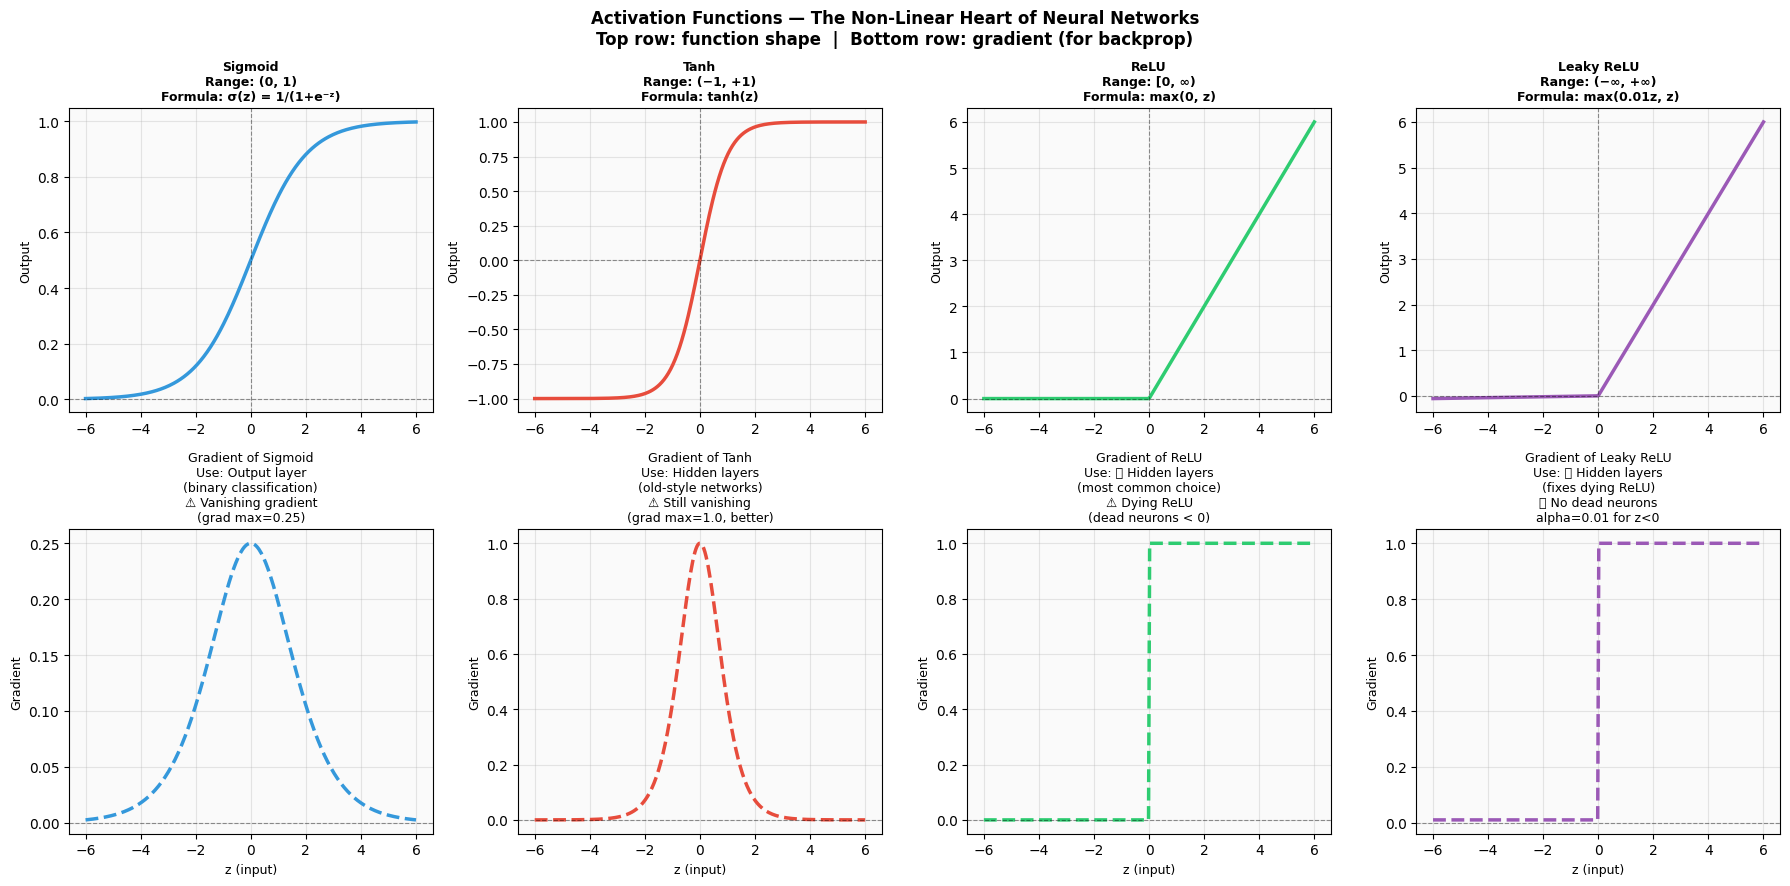


🔑 THE CHEAT SHEET:
Hidden layers  → ReLU (fast, simple, works)
Output (binary classification) → Sigmoid (gives probability)
Output (multi-class)  → Softmax (gives class probabilities)
Output (regression)   → Linear/None (predict any number)

WHY ReLU won over Sigmoid for hidden layers:
Sigmoid gradient MAX = 0.25 → multiplied many times = vanishes
ReLU gradient = 1 (when active) → no shrinking!


In [ ]:
# ══════════════════════════════════════════════════════
# ALL ACTIVATION FUNCTIONS — Visualised and Explained
# ══════════════════════════════════════════════════════

z = np.linspace(-6, 6, 300)

# ── Define all activations ──
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_grad(z):
    s = sigmoid(z)
    return s * (1 - s)    # max value = 0.25 at z=0

def tanh(z):
    return np.tanh(z)

def tanh_grad(z):
    return 1 - np.tanh(z)**2  # max value = 1.0 at z=0

def relu(z):
    return np.maximum(0, z)

def relu_grad(z):
    return (z > 0).astype(float)  # 1 if z>0, else 0

def leaky_relu(z, alpha=0.01):
    return np.where(z > 0, z, alpha * z)

def leaky_relu_grad(z, alpha=0.01):
    return np.where(z > 0, 1.0, alpha)

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

activation_info = [
    {
        'name': 'Sigmoid',
        'func': sigmoid(z),
        'grad': sigmoid_grad(z),
        'color': '#3498DB',
        'range': '(0, 1)',
        'use': 'Output layer\n(binary classification)',
        'problem': '⚠️ Vanishing gradient\n(grad max=0.25)',
        'formula': 'σ(z) = 1/(1+e⁻ᶻ)'
    },
    {
        'name': 'Tanh',
        'func': tanh(z),
        'grad': tanh_grad(z),
        'color': '#E74C3C',
        'range': '(−1, +1)',
        'use': 'Hidden layers\n(old-style networks)',
        'problem': '⚠️ Still vanishing\n(grad max=1.0, better)',
        'formula': 'tanh(z)'
    },
    {
        'name': 'ReLU',
        'func': relu(z),
        'grad': relu_grad(z),
        'color': '#2ECC71',
        'range': '[0, ∞)',
        'use': '✅ Hidden layers\n(most common choice)',
        'problem': '⚠️ Dying ReLU\n(dead neurons < 0)',
        'formula': 'max(0, z)'
    },
    {
        'name': 'Leaky ReLU',
        'func': leaky_relu(z),
        'grad': leaky_relu_grad(z),
        'color': '#9B59B6',
        'range': '(−∞, +∞)',
        'use': '✅ Hidden layers\n(fixes dying ReLU)',
        'problem': '✅ No dead neurons\nalpha=0.01 for z<0',
        'formula': 'max(0.01z, z)'
    },
]

for col, info in enumerate(activation_info):
    # Top row: activation function
    ax_top = axes[0, col]
    ax_top.plot(z, info['func'],
                color=info['color'], linewidth=2.5)
    ax_top.axhline(0, color='black',
                    linewidth=0.8, linestyle='--', alpha=0.4)
    ax_top.axvline(0, color='black',
                    linewidth=0.8, linestyle='--', alpha=0.4)
    ax_top.set_title(
        f"{info['name']}\n"
        f"Range: {info['range']}\n"
        f"Formula: {info['formula']}",
        fontsize=9, fontweight='bold')
    ax_top.set_ylabel("Output", fontsize=9)
    ax_top.grid(alpha=0.3)
    ax_top.set_facecolor('#FAFAFA')

    # Bottom row: gradient
    ax_bot = axes[1, col]
    ax_bot.plot(z, info['grad'],
                color=info['color'],
                linewidth=2.5, linestyle='--')
    ax_bot.axhline(0, color='black',
                    linewidth=0.8, linestyle='--', alpha=0.4)
    ax_bot.set_title(
        f"Gradient of {info['name']}\n"
        f"Use: {info['use']}\n"
        f"{info['problem']}",
        fontsize=9)
    ax_bot.set_ylabel("Gradient", fontsize=9)
    ax_bot.set_xlabel("z (input)", fontsize=9)
    ax_bot.grid(alpha=0.3)
    ax_bot.set_facecolor('#FAFAFA')

plt.suptitle(
    "Activation Functions — The Non-Linear Heart of Neural Networks\n"
    "Top row: function shape  |  Bottom row: gradient (for backprop)",
    fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n🔑 THE CHEAT SHEET:")
print("Hidden layers  → ReLU (fast, simple, works)")
print("Output (binary classification) → Sigmoid (gives probability)")
print("Output (multi-class)  → Softmax (gives class probabilities)")
print("Output (regression)   → Linear/None (predict any number)")
print()
print("WHY ReLU won over Sigmoid for hidden layers:")
print("Sigmoid gradient MAX = 0.25 → multiplied many times = vanishes")
print("ReLU gradient = 1 (when active) → no shrinking!")

**Vanishing Gradient Problem**

Analogy: telephone whisper game

You whisper a message through 10 people, by person 10, the message is completely garbled. In backprop: the gradient (error signal) gets multiplies by the activation gradient at each layer.

Sigmoid max gradient = 0.25
- After 5 layers: 0.25^5 =", 0.25**5
- After 8 layers: 0.25^8 =", 0.25**8
- After 10 layers: 0.25^10 =", 0.25**10

The first layers recieve essentially Zero gradient. They stop learning. The network is effectively shallow.

ReLU gradient = 1.0 (when active)
- After 10 layers: 1.0^10 =", 1.0**10

Gradient stays strong, first layers keep learning.

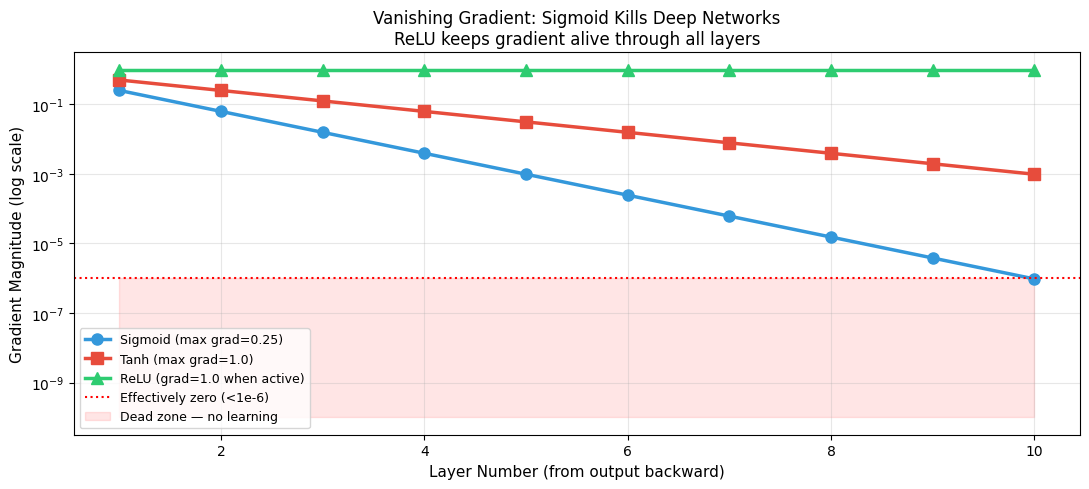

In [ ]:
# VANISHING GRADIENT
# Visualise gradient magnitude through layers
n_layers = 10
layers = list(range(1, n_layers + 1))

grad_sigmoid = [0.25**i for i in layers]
grad_tanh    = [0.5**i  for i in layers]
grad_relu    = [1.0**i  for i in layers]

plt.figure(figsize=(11, 5))
plt.semilogy(layers, grad_sigmoid, 'o-',
             color='#3498DB', linewidth=2.5,
             markersize=8, label='Sigmoid (max grad=0.25)')
plt.semilogy(layers, grad_tanh, 's-',
             color='#E74C3C', linewidth=2.5,
             markersize=8, label='Tanh (max grad=1.0)')
plt.semilogy(layers, grad_relu, '^-',
             color='#2ECC71', linewidth=2.5,
             markersize=8, label='ReLU (grad=1.0 when active)')

plt.axhline(1e-6, color='red', linestyle=':',
            linewidth=1.5, label='Effectively zero (<1e-6)')
plt.fill_between(layers,
                  [1e-10]*len(layers),
                  [1e-6]*len(layers),
                  alpha=0.1, color='red',
                  label='Dead zone — no learning')

plt.xlabel("Layer Number (from output backward)", fontsize=11)
plt.ylabel("Gradient Magnitude (log scale)", fontsize=11)
plt.title(
    "Vanishing Gradient: Sigmoid Kills Deep Networks\n"
    "ReLU keeps gradient alive through all layers",
    fontsize=12)
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Backpropagation**

The analogy, a chef adjusting a recipe:

A chef makes a dish and it tastes bad. She needs to figure out which ingredinet to change and by how much, She goes back through the recipe, asking: "Did the salt affect the final taste? By how much? Did the cooking time? By how much?"

She goea backward through each step, measuring each ingredient's contribution to the bad outcome.

That is backpropagation. The "bad outcome" is the loss. The "ingredients" are the weights. Going backwards through each layer measuring contribution is the chain rule.

**The chain rule**

If y depends on x through some function f:
- y=f(x)
- dy/dx = f'(x) <- simple derivative

If z depends on y, and y depends on x:
- z=g(f(x))
- dz/dx=dz/dy × dy/dx <- Chain Rule

In a neural network with 3 layers:
- Loss->Layer3->Layer2->Layer1->Input
- dLoss/dw1=dLoss/dLayer3 × dLayer3/dLayer2 ×  dLayer2/dLayer1 × dLayer1/dw1

Each layer computes its LOCAL gradient.

Multiplies together=full gradient for any weight.

In [ ]:
class NeuralNetworkFromScratch:
  def __init__(self, layer_sizes, learning_rate=0.01, random_state=42):
    # layer_sizes: list like [input_dim, 64, 32, output_dim]
    np.random.seed(random_state)
    self.lr=learning_rate
    self.sizes=layer_sizes
    self.params={} # Corrected typo from self.prams
    self.loss_history=[]
    self.acc_history=[]

    # Initialize weights
    # He initialization for Relu layers
    # Rule: scale by sqrt(2/fan_in)
    # Why? keeps varinace of activations stable through layers
    # If weights are too large -> exploding activations
    # If weights are too small -> vanishing activations
    for i in range(1, len(layer_sizes)):
      fan_in=layer_sizes[i-1]
      # He init (best for Relu Networks)
      scale = np.sqrt(2.0 / fan_in)
      self.params[f'W{i}'] = (
          np.random.randn(layer_sizes[i-1],
                                layer_sizes[i]) * scale)
      self.params[f'b{i}'] = np.zeros(layer_sizes[i])

    print(f"Network created:")
    for i in range(1, len(layer_sizes)):
        print(f"   Layer {i}: "
              f"{layer_sizes[i-1]} → {layer_sizes[i]} "
              f"| W shape: {self.params[f'W{i}'].shape}")

  # ACTIVATION FUNCTIONS
  def relu(self, z):
    return np.maximum(0, z)

  def relu_grad(self, z):
    # Gradient of RelU: 1 where z>0, 0 where z<=0
    return (z > 0).astype(float)

  def sigmoid(self, z):
      # Numerically stable version
      return np.where(
          z >= 0,
          1 / (1 + np.exp(-z)),
          np.exp(z) / (1 + np.exp(z)))

  def sigmoid_grad(self, z):
    s = self.sigmoid(z)
    return s * ( 1- s)

  # Loss Function
  def binary_cross_entropy(self, y_true, y_pred):
    # Clip to prevent log(0)
    y_pred=np.clip(y_pred, 1e-10, 1 - 1e-10)
    return -np.mean(
        y_true * np.log(y_pred) +
        (1 - y_true) * np.log(1 - y_pred))

  # FORWARD PASS
  # Data flows: Input → Layer1 → Layer2 → Output
  # We STORE intermediate values for backprop

  def forward(self, X):
    # X shape: (batch_size, n_features)
    # return Output predictions
    # Stores cache for backward pass

    self.cache = {} # Store everything for backprop

    # Input layer
    self.cache['a0']=X

    # Hidden layer 1:
    # Z = X * W + b (Linear Transformation)
    # a = ReLU(z) (non-linear activation)
    self.cache['z1'] = (X @ self.params['W1'] + self.params['b1'])
    self.cache['a1'] = self.relu(self.cache['z1'])

    # Hidden Layer 2
    self.cache['z2'] = (self.cache['a1'] @ self.params['W2'] + self.params['b2'])
    self.cache['a2'] = self.relu(self.cache['z2'])

    # Output Layer
    # Sigmoid -> output is a probability (0 to 1)
    self.cache['z3'] = (self.cache['a2'] @ self.params['W3'] + self.params['b3'])
    self.cache['a3'] = self.sigmoid(self.cache['z3'])

    return self.cache['a3']


  # Backward Pass (backpropagation)
  # Gradienrs flow: Output-> Layer 2-> layer 1-> Input
  # Chain Rule applied at every step

  def backward(self, y_true):
    # Compute gradienrs for all weights and biases.
    # Uses cached values from forward pass.
    # Returns dict of gradients.

    grads={}
    m=len(y_true) #batch_size
    y_pred=self.cache['a3']

    # Output Layer Gradient
    # dL/dz3=dL/da3 × da3/dz3
    # For cross-entropy + sigmoid, this simplifies to:
    # dL/dz3 = (y_pred - y_true)/m
    dL_dz3 = (y_pred.squeeze() - y_true) / m
    dL_dz3 = dL_dz3.reshape(-1, 1)

    # Gradient for w3 and b3
    # dL/W3=a2.T @ dL/dZ3
    grads['W3'] = self.cache['a2'].T @ dL_dz3
    grads['b3'] = dL_dz3.sum(axis=0)

    # Hidden Layer 2 gradient
    # chain rule: pass gradient back through w3
    dL_da2=dL_dz3 @ self.params['W3'].T
    # then through ReLU activation
    dL_dz2 = dL_da2 * self.relu_grad(self.cache['z2'])
    grads['W2'] = self.cache['a1'].T @ dL_dz2
    grads['b2'] = dL_dz2.sum(axis=0)

    # Hidden layer 1 Gradient
    # Chain rule: pass gradient back through w2
    dL_da1 = dL_dz2 @ self.params['W2'].T
    # then through ReLU activation
    dL_dz1 = dL_da1 * self.relu_grad(self.cache['z1'])

    grads['W1'] = self.cache['a0'].T @ dL_dz1
    grads['b1'] = dL_dz1.sum(axis=0)

    return grads

  # Update Weights (Gradient Descent)
  def update_weights(self, grads):
    # Move weights in the direction that reduces loss.
    # W = W - learning_rate × gradient
    for i in range(1, len(self.sizes)):
        self.params[f'W{i}'] -= self.lr * grads[f'W{i}']
        self.params[f'b{i}'] -= self.lr * grads[f'b{i}']

  # Training Loop
  def fit(self, X, Y, epochs=1000, batch_size=32, verbose=True):
    # For training loop:
    # For each epoch:
    # 1. Shuffle data
    # 2. Split into mini-batches
    # 3. Forward pass
    # 4. Compute loss
    # 5. Backward pass
    # 6. Update weights
    # 7. Repeat

    n=len(X)

    for epoch in range(epochs):
      # Shuffle data each epoch
      # Prevents the model from memorizing order
      shuffle_idx = np.random.permutation(n)
      X_shuffled  = X[shuffle_idx]
      y_shuffled  = Y[shuffle_idx]

      epoch_loss=0
      n_batches=0

      # Mini-batch gradient descent
      for start in range(0, n, batch_size):
        end=min(start+batch_size, n)
        X_batch = X_shuffled[start:end]
        y_batch = y_shuffled[start:end]

        # Forward
        y_pred=self.forward(X_batch)

        # loss
        loss = self.binary_cross_entropy(y_batch, y_pred.squeeze())
        epoch_loss += loss
        n_batches += 1

        # Backward
        grads=self.backward(y_batch)

        # update
        self.update_weights(grads)

      # Track progress
      avg_loss = epoch_loss / n_batches
      y_pred_all = self.forward(X).squeeze()
      acc = accuracy_score(
          Y, (y_pred_all >= 0.5).astype(int))

      self.loss_history.append(avg_loss)
      self.acc_history.append(acc)

      if verbose and epoch % 100 == 0:
        print(f"Epoch {epoch:4d} | "
                      f"Loss: {avg_loss:.4f} | "
                      f"Acc: {acc:.4f}")

    return self

  def predict_proba(self, X):
      return self.forward(X).squeeze()

  def predict(self, X, threshold=0.5):
      return (self.predict_proba(X) >= threshold).astype(int)



Test 1: Simple Classification
---------------------------------------------
Network created:
   Layer 1: 2 → 16 | W shape: (2, 16)
   Layer 2: 16 → 18 | W shape: (16, 18)
   Layer 3: 18 → 1 | W shape: (18, 1)

 Training..
Epoch    0 | Loss: 0.6810 | Acc: 0.8775
Epoch  100 | Loss: 0.1223 | Acc: 0.9600
Epoch  200 | Loss: 0.0856 | Acc: 0.9675
Epoch  300 | Loss: 0.0786 | Acc: 0.9750
Epoch  400 | Loss: 0.0743 | Acc: 0.9800

 Train Accuracy: 0.9750
 Test  Accuracy: 0.9900


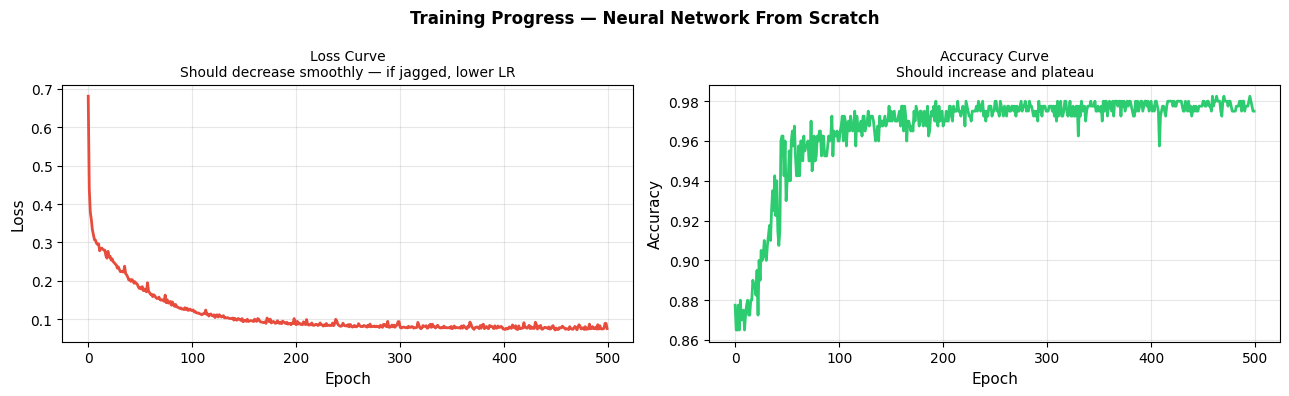

In [ ]:
# Test 1: Simple Linearly Separable data
print("Test 1: Simple Classification")
print("-" * 45)

X_simple, y_simple = make_classification(n_samples=500, n_features=2, n_redundant=0,
                                         n_informative=2, n_clusters_per_class=1,
                                         random_state=42)
X_tr, X_te, y_tr, y_te=train_test_split(X_simple, y_simple, test_size=0.2, random_state=42)

scaler=StandardScaler()
X_tr_s=scaler.fit_transform(X_tr)
X_te_s=scaler.transform(X_te)

#Build network: 2 inputs -> 16 neurons -> 8 neurons -> 1 output
nn=NeuralNetworkFromScratch(layer_sizes=[2, 16, 18, 1], learning_rate=0.05)

print("\n Training..")
nn.fit(X_tr_s, y_tr, epochs=500,
       batch_size=32, verbose=True)

train_acc = accuracy_score(y_tr, nn.predict(X_tr_s))
test_acc  = accuracy_score(y_te, nn.predict(X_te_s))
print(f"\n Train Accuracy: {train_acc:.4f}")
print(f" Test  Accuracy: {test_acc:.4f}")

# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(nn.loss_history,
             color='#E74C3C', linewidth=2)
axes[0].set_xlabel("Epoch", fontsize=11)
axes[0].set_ylabel("Loss", fontsize=11)
axes[0].set_title(
    "Loss Curve\n"
    "Should decrease smoothly — if jagged, lower LR",
    fontsize=10)
axes[0].grid(alpha=0.3)

axes[1].plot(nn.acc_history,
             color='#2ECC71', linewidth=2)
axes[1].set_xlabel("Epoch", fontsize=11)
axes[1].set_ylabel("Accuracy", fontsize=11)
axes[1].set_title(
    "Accuracy Curve\n"
    "Should increase and plateau",
    fontsize=10)
axes[1].grid(alpha=0.3)

plt.suptitle("Training Progress — Neural Network From Scratch",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

Test 2: Non-linear data (Moon Shapes)
This is where Neural Networks beat logistic regression
---------------------------------------------
Network created:
   Layer 1: 2 → 32 | W shape: (2, 32)
   Layer 2: 32 → 16 | W shape: (32, 16)
   Layer 3: 16 → 1 | W shape: (16, 1)
Logistic Regression accuracy: 0.8500
Neural Network accuracy:      1.0000
Neural net improvement:       +15.0%


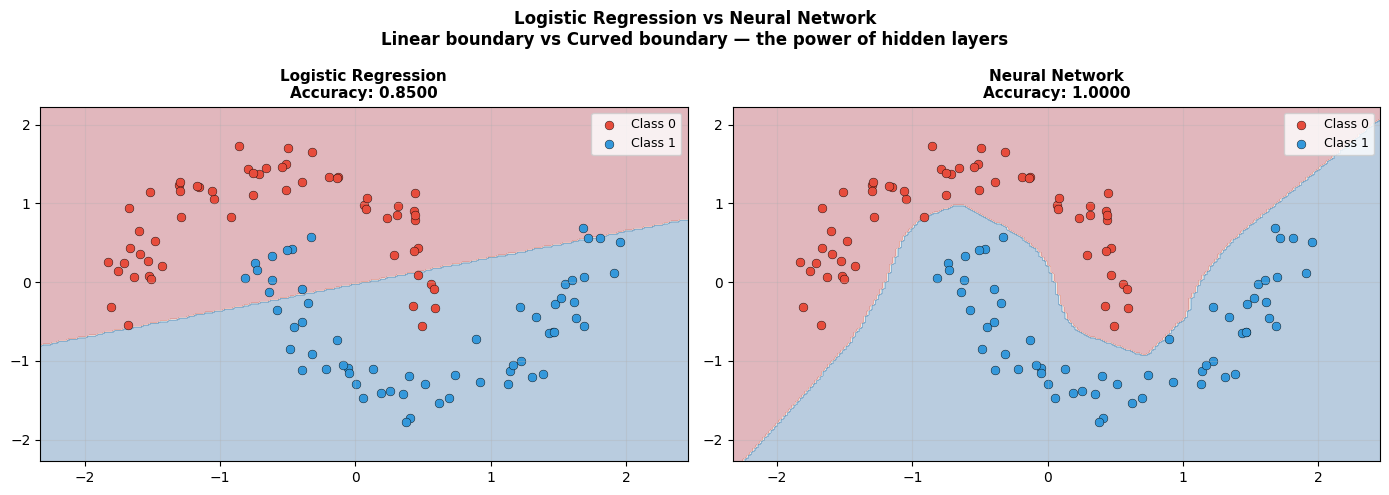

In [ ]:
# Test 2: the Real Test - non-linear data
# logistic regression would fail here

print("Test 2: Non-linear data (Moon Shapes)")
print("This is where Neural Networks beat logistic regression")
print("-" * 45)

X_moon, y_moon = make_moons(n_samples=600, noise=0.1, random_state=42)

X_tr_m, X_te_m, y_tr_m, y_te_m=train_test_split(X_moon, y_moon, test_size=0.2, random_state=42)

scaler_m= StandardScaler()
X_tr_ms=scaler_m.fit_transform(X_tr_m)
X_te_ms=scaler_m.transform(X_te_m)

#Compare logistic regression vs neural network
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression()
lr_model.fit(X_tr_ms, y_tr_m)
lr_acc = accuracy_score(y_te_m, lr_model.predict(X_te_ms))

nn_moon = NeuralNetworkFromScratch(
    layer_sizes=[2, 32, 16, 1],
    learning_rate=0.05)
nn_moon.fit(X_tr_ms, y_tr_m,
             epochs=800, batch_size=32,
             verbose=False)
nn_acc = accuracy_score(y_te_m, nn_moon.predict(X_te_ms))

print(f"Logistic Regression accuracy: {lr_acc:.4f}")
print(f"Neural Network accuracy:      {nn_acc:.4f}")
print(f"Neural net improvement:       "
      f"+{(nn_acc-lr_acc)*100:.1f}%")


# Visualise decision boundaries
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x_min = X_te_ms[:,0].min()-0.5
x_max = X_te_ms[:,0].max()+0.5
y_min = X_te_ms[:,1].min()-0.5
y_max = X_te_ms[:,1].max()+0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200))
grid = np.c_[xx.ravel(), yy.ravel()]

for ax, model, name, acc in zip(
        axes,
        [lr_model, nn_moon],
        ['Logistic Regression', 'Neural Network'],
        [lr_acc, nn_acc]):

    if name == 'Logistic Regression':
        Z = model.predict(grid)
    else:
        Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    ax.scatter(X_te_ms[y_te_m==0,0],
               X_te_ms[y_te_m==0,1],
               c='#E74C3C', s=40,
               edgecolors='k', linewidth=0.3,
               label='Class 0')
    ax.scatter(X_te_ms[y_te_m==1,0],
               X_te_ms[y_te_m==1,1],
               c='#3498DB', s=40,
               edgecolors='k', linewidth=0.3,
               label='Class 1')
    ax.set_title(
        f"{name}\nAccuracy: {acc:.4f}",
        fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle(
    "Logistic Regression vs Neural Network\n"
    "Linear boundary vs Curved boundary — "
    "the power of hidden layers",
    fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

Demonstrating learning rate effect...
Network created:
   Layer 1: 2 → 16 | W shape: (2, 16)
   Layer 2: 16 → 8 | W shape: (16, 8)
   Layer 3: 8 → 1 | W shape: (8, 1)
Network created:
   Layer 1: 2 → 16 | W shape: (2, 16)
   Layer 2: 16 → 8 | W shape: (16, 8)
   Layer 3: 8 → 1 | W shape: (8, 1)
Network created:
   Layer 1: 2 → 16 | W shape: (2, 16)
   Layer 2: 16 → 8 | W shape: (16, 8)
   Layer 3: 8 → 1 | W shape: (8, 1)


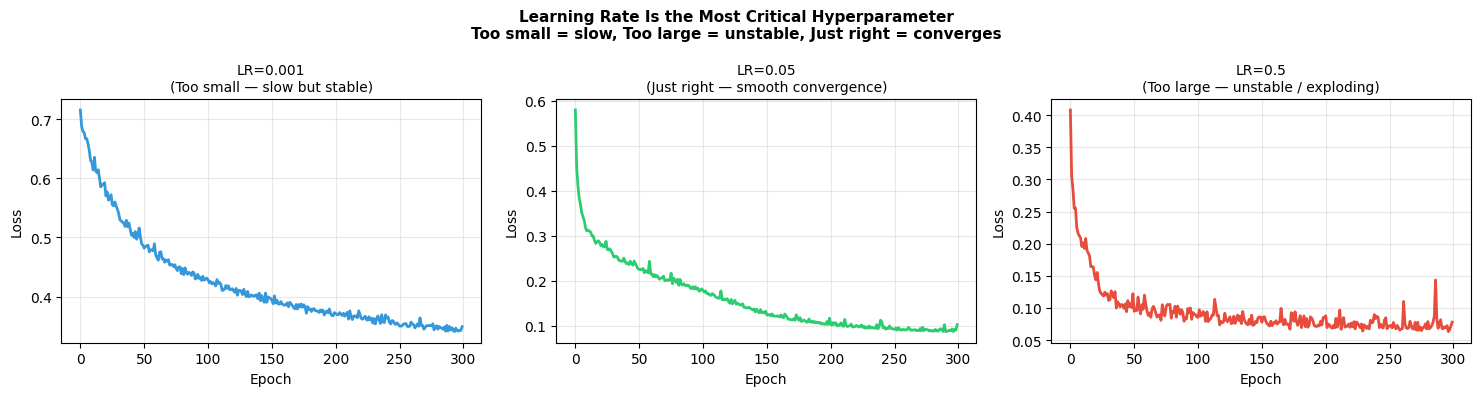

In [ ]:
# Visualise: effect of learning rate on training
print("Demonstrating learning rate effect...")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
learning_rates = [0.001, 0.05, 0.5]
titles = [
    "LR=0.001\n(Too small — slow but stable)",
    "LR=0.05\n(Just right — smooth convergence)",
    "LR=0.5\n(Too large — unstable / exploding)"
]
colors_lr = ['#3498DB', '#2ECC71', '#E74C3C']

for ax, lr, title, color in zip(
        axes, learning_rates, titles, colors_lr):
    nn_lr = NeuralNetworkFromScratch(
        layer_sizes=[2, 16, 8, 1],
        learning_rate=lr,
        random_state=42)
    nn_lr.fit(X_tr_s, y_tr, epochs=300,
              batch_size=32, verbose=False)

    loss_clean = [l for l in nn_lr.loss_history
                   if not np.isnan(l) and l < 10]

    ax.plot(loss_clean, color=color, linewidth=2)
    ax.set_xlabel("Epoch", fontsize=10)
    ax.set_ylabel("Loss", fontsize=10)
    ax.set_title(title, fontsize=10)
    ax.grid(alpha=0.3)

plt.suptitle(
    "Learning Rate Is the Most Critical Hyperparameter\n"
    "Too small = slow, Too large = unstable, Just right = converges",
    fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
print("""
╔══════════════════════════════════════════════════════════╗
║        NEURAL NETWORK FAILURE MODES & FIXES             ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  PROBLEM 1: Loss Not Decreasing                         ║
║  ─────────────────────────────────────────────────────  ║
║  Symptom:  Loss stays flat from epoch 1                  ║
║  Causes:   Learning rate too small OR too large          ║
║            Weights initialised poorly                    ║
║            Bug in forward/backward pass                  ║
║  Fix:      Try lr=0.001, 0.01, 0.1 (log scale search)   ║
║            Use He init for ReLU, Xavier for sigmoid/tanh ║
║            Check shapes with print statements            ║
║                                                          ║
║  PROBLEM 2: Loss Exploding (NaN)                        ║
║  ─────────────────────────────────────────────────────  ║
║  Symptom:  Loss goes to NaN after a few steps            ║
║  Causes:   Learning rate WAY too large                   ║
║            No input normalisation                        ║
║  Fix:      Reduce learning rate by 10x                   ║
║            ALWAYS normalise inputs (StandardScaler)      ║
║            Add gradient clipping (clip at 5.0)           ║
║                                                          ║
║  PROBLEM 3: Overfitting                                  ║
║  ─────────────────────────────────────────────────────  ║
║  Symptom:  Train acc=99%, Val acc=70%                    ║
║  Causes:   Model too large for data                      ║
║            Not enough training data                      ║
║  Fix:      Dropout (randomly disable neurons)            ║
║            L2 regularisation on weights                  ║
║            Early stopping                                ║
║            Data augmentation                             ║
║                                                          ║
║  PROBLEM 4: Vanishing Gradient                          ║
║  ─────────────────────────────────────────────────────  ║
║  Symptom:  First layers barely update                    ║
║            Deep network performs like shallow one        ║
║  Causes:   Sigmoid/tanh in hidden layers                 ║
║            Too many layers without residual connections  ║
║  Fix:      Use ReLU/Leaky ReLU in hidden layers          ║
║            Add residual connections (ResNet style)       ║
║            Batch Normalisation between layers            ║
║                                                          ║
║  PROBLEM 5: Dying ReLU                                  ║
║  ─────────────────────────────────────────────────────  ║
║  Symptom:  Accuracy plateaus early, won't improve        ║
║  Causes:   Many neurons stuck at z<0 forever             ║
║            Large learning rate killed neurons            ║
║  Fix:      Use Leaky ReLU instead of ReLU                ║
║            Reduce learning rate                          ║
║            He initialisation (prevents early death)      ║
║                                                          ║
╚══════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════╗
║        NEURAL NETWORK FAILURE MODES & FIXES             ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  PROBLEM 1: Loss Not Decreasing                         ║
║  ─────────────────────────────────────────────────────  ║
║  Symptom:  Loss stays flat from epoch 1                  ║
║  Causes:   Learning rate too small OR too large          ║
║            Weights initialised poorly                    ║
║            Bug in forward/backward pass                  ║
║  Fix:      Try lr=0.001, 0.01, 0.1 (log scale search)   ║
║            Use He init for ReLU, Xavier for sigmoid/tanh ║
║            Check shapes with print statements            ║
║                                                          ║
║  PROBLEM 2: Loss Exploding (NaN)                        ║
║  ─────────────────────────────────────────────────────  ║
║  Symptom:  Loss goes to NaN